# 01 — Exploratory data analysis (Phase 3)

**Owner:** M3 (with M1's Phase 1 profiling and EDA 8) · **Data:** Zindi Swahili Audio Classification, 4,200 labelled clips of 12 spoken words.

Every analysis ends with a **→ Decision** that says how it shaped the modelling. The final cell collects these decisions into one table.

**Protocol.**
- Distributions (durations, loudness, SNR, pitch, spectra, feature space) are measured on the **training split only**, so no design decision is informed by validation or test clips.
- Counts and integrity checks (file format, duplicates, leakage) use all labelled clips.
- Heavy per-clip statistics are cached in `results/metrics/`, so the notebook re-executes in about a minute. `RERUN = True` recomputes them.

In [1]:
import glob, os, shutil, sys, subprocess

REPO_URL = "https://github.com/Hassan-Adelani-Luqman/nlp-sequential-modeling-group21.git"
REPO_DIR = "nlp-sequential-modeling-group21"
if os.path.isdir("/kaggle/input") or "google.colab" in sys.modules:
    # A code-snapshot dataset attached on Kaggle takes precedence over GitHub (lets you run code before it is pushed).
    snapshot = glob.glob("/kaggle/input/**/src/train_torch.py", recursive=True) if os.path.isdir("/kaggle/input") else []
    zipped = glob.glob("/kaggle/input/**/group21-code*.zip", recursive=True) if os.path.isdir("/kaggle/input") else []
    if not snapshot and zipped:  # the archive was not unpacked on upload: unpack it ourselves
        import zipfile
        zipfile.ZipFile(zipped[0]).extractall("/tmp/snapshot")
        snapshot = glob.glob("/tmp/snapshot/**/src/train_torch.py", recursive=True)
    if snapshot:
        REPO_DIR = "/tmp/" + REPO_DIR   # outside /kaggle/working, so only results are saved as outputs
        if not os.path.isdir(REPO_DIR):
            shutil.copytree(os.path.dirname(os.path.dirname(snapshot[0])), REPO_DIR)
        print("using code snapshot:", os.path.dirname(os.path.dirname(snapshot[0])))
    elif not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if os.path.isdir("/kaggle/working"):
        # Kaggle writes outputs to /kaggle/working, which starts empty: seed it with the repo's logged runs
        # (and any checkpoints shipped with the code snapshot) so finished runs are reused, not retrained.
        for folder in ("results", "checkpoints"):
            if os.path.isdir(folder):
                shutil.copytree(folder, os.path.join("/kaggle/working", folder), dirs_exist_ok=True)
        os.environ.setdefault("SWN_CACHE_DIR", "/tmp/swn_feature_cache")  # recomputable: keep it out of the outputs
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Image, display
from joblib import Parallel, delayed

from src.data import audio_dir, label_names, load_splits, load_audio, TARGET_SR
from src.evaluate import load_predictions
from src.features import PRESETS, cached_features, energy_crop, trim_silence
from src.paths import SPLITS_DIR, REPO_ROOT, results_dir
from src.plotting import DEEMPHASIS, INK, INK_SECONDARY, SERIES, apply_style, blue_cmap, save_figure

RERUN = False
apply_style()
NAMES = label_names()
splits = load_splits()
train = splits["train"]
manifest = json.loads((SPLITS_DIR / "manifest.json").read_text(encoding="utf-8"))
GLOSS = manifest["glosses"]
RES = results_dir()
(RES / "metrics").mkdir(parents=True, exist_ok=True)
print({k: len(v) for k, v in splits.items()}, "| split hash", manifest["split_hash"][:8])

{'train': 2940, 'val': 630, 'test': 630} | split hash b74d294f


## 1. Class balance

In [3]:
counts = pd.DataFrame({name: df.label.value_counts().reindex(NAMES) for name, df in splits.items()})
counts["gloss"] = [GLOSS[w] for w in counts.index]
display(counts[["gloss", "train", "val", "test"]].T)
print("per-word totals:", sorted(set((counts.train + counts.val + counts.test).tolist())))

label,hapana,kumi,mbili,moja,nane,ndio,nne,saba,sita,tano,tatu,tisa
gloss,no,ten,two,one,eight,yes,four,seven,six,five,three,nine
train,245,245,245,245,245,245,245,245,245,245,245,245
val,53,52,53,52,52,53,52,52,53,53,53,52
test,52,53,52,53,53,52,53,53,52,52,52,53


per-word totals: [350]


**→ Decision.** The classes are perfectly balanced (350 clips per word; 245 / 52–53 / 52–53 per split).
- No class weighting or resampling is needed.
- Accuracy is not inflated by a majority class, so it is a fair headline metric alongside macro-F1 and the official log loss.

## 2. File properties (all 6,000 recordings, including the unlabelled competition test clips)

In [4]:
import soundfile as sf

wavs = sorted(audio_dir().glob("*.wav"))
info = pd.DataFrame([(p.name, *(lambda i: (i.samplerate, i.channels, i.subtype, i.frames / i.samplerate))(sf.info(str(p))))
                     for p in wavs], columns=["file", "sample_rate", "channels", "subtype", "seconds"])
summary = {"files": len(info), "sample rates": info.sample_rate.value_counts().to_dict(),
           "channels": info.channels.value_counts().to_dict(), "encoding": info.subtype.value_counts().to_dict(),
           "duration (s)": info.seconds.describe(percentiles=[.05, .5, .95]).round(2).to_dict()}
for k, v in summary.items():
    print(f"{k:14s} {v}")
print("byte-identical duplicates among labelled clips (Phase 1):", manifest["source"]["n_duplicates_dropped"])

files          6000
sample rates   {16000: 6000}
channels       {1: 6000}
encoding       {'PCM_16': 6000}
duration (s)   {'count': 6000.0, 'mean': 4.81, 'std': 3.33, 'min': 2.16, '5%': 3.2, '50%': 4.32, '95%': 7.28, 'max': 62.24}
byte-identical duplicates among labelled clips (Phase 1): 0


**→ Decision.**
- Every file is 16 kHz, mono, 16-bit PCM, so no resampling or channel mixing is needed.
- 16 kHz is also the rate that wav2vec2 / XLS-R (A5) were pretrained on.
- There are no corrupt files and no byte-identical duplicates.

## 3–4. Duration, silence, loudness and noise (training split)

In [5]:
def clip_stats(path):
    wav = load_audio(path)
    frame = 400                                                     # 25 ms
    n = len(wav) // frame * frame
    fp = (wav[:n].reshape(-1, frame).astype(np.float64) ** 2).mean(1) + 1e-12
    fdb = 10 * np.log10(fp)
    speech = fdb >= fdb.max() - 25                                  # frames within 25 dB of the clip's peak
    noise_db = 10 * np.log10(np.percentile(fp, 20))                 # the quietest 20% of frames ~ the noise floor
    win = energy_crop(wav, 1.5)
    wp = (win[: len(win) // frame * frame].reshape(-1, frame).astype(np.float64) ** 2).mean(1) + 1e-12
    wdb = 10 * np.log10(wp)
    return {"id": os.path.basename(path), "clip_s": len(wav) / TARGET_SR,
            "trimmed_s": len(trim_silence(wav, top_db=30)) / TARGET_SR,
            "word_s": float((wdb >= wdb.max() - 25).sum() * frame / TARGET_SR),   # loud frames inside the 1.5 s window
            "rms_dbfs": float(10 * np.log10(fp.mean())), "peak": float(np.abs(wav).max()),
            "snr_db": float(10 * np.log10(fp[speech].mean()) - noise_db)}


stats_file = RES / "metrics" / "eda_clip_stats.csv"
if stats_file.exists() and not RERUN:
    stats = pd.read_csv(stats_file)
else:
    stats = pd.DataFrame(Parallel(n_jobs=-1)(delayed(clip_stats)(p) for p in train.path))
    stats.to_csv(stats_file, index=False)
stats = stats.merge(train[["id", "label"]], on="id")
display(stats[["clip_s", "trimmed_s", "word_s", "rms_dbfs", "snr_db"]].describe(percentiles=[.05, .5, .95]).round(2))
print(f"clips with peak >= 0.99 (possible clipping): {(stats.peak >= 0.99).mean():.1%}")

,clip_s,trimmed_s,word_s,rms_dbfs,snr_db
count,2940.00,2940.00,2940.00,2940.00,2940.00
mean,4.76,2.36,0.63,-32.09,40.30
std,2.99,3.03,0.29,6.01,12.82
min,2.48,0.38,0.20,-64.61,2.84
5%,3.12,0.51,0.35,-42.07,16.13
50%,4.32,1.86,0.55,-31.69,41.66
95%,7.28,5.47,1.40,-23.02,61.31
max,62.24,62.19,1.50,-16.24,88.03


clips with peak >= 0.99 (possible clipping): 3.8%


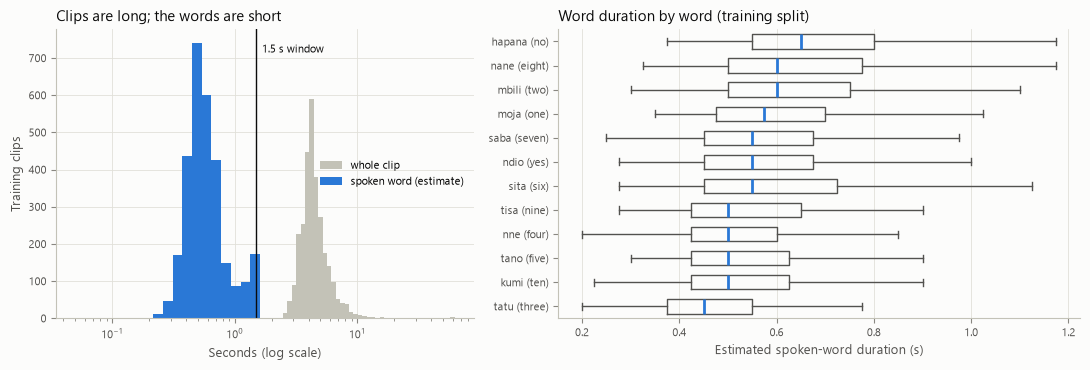

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
bins = np.logspace(np.log10(stats.clip_s.min()), np.log10(stats.clip_s.max()), 40)
ax.hist(stats.clip_s, bins=bins, color=DEEMPHASIS, label="whole clip")
ax.hist(stats.word_s, bins=np.logspace(np.log10(0.05), np.log10(stats.clip_s.max()), 40), color=SERIES[0], label="spoken word (estimate)")
ax.set_xscale("log")
ax.set_xlabel("Seconds (log scale)")
ax.set_ylabel("Training clips")
ax.axvline(1.5, color=INK, lw=1)
ax.annotate("1.5 s window", (1.5, ax.get_ylim()[1] * 0.92), xytext=(4, 0), textcoords="offset points", fontsize=8, color=INK)
ax.legend(loc="center right")
ax.set_title("Clips are long; the words are short", loc="left")

ax = axes[1]
order = stats.groupby("label").word_s.median().sort_values().index.tolist()
import matplotlib
horizontal = {"orientation": "horizontal"} if tuple(map(int, matplotlib.__version__.split(".")[:2])) >= (3, 10) else {"vert": False}
ax.boxplot([stats.loc[stats.label == w, "word_s"] for w in order], **horizontal, widths=0.6, showfliers=False,
           medianprops={"color": SERIES[0], "lw": 2}, boxprops={"color": INK_SECONDARY}, whiskerprops={"color": INK_SECONDARY},
           capprops={"color": INK_SECONDARY})
ax.set_yticks(range(1, len(order) + 1), [f"{w} ({GLOSS[w]})" for w in order])
ax.set_xlabel("Estimated spoken-word duration (s)")
ax.set_title("Word duration by word (training split)", loc="left")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "eda_durations")
plt.show()

**→ Decision.**
- **The words are short, and the clips are long.** Clips last 2.5–62 s (median 4.3 s), but the spoken word is short: a median 0.55 s. It ranges from 0.45 s for *tatu* to 0.65 s for the three-syllable *hapana*, and 89.5% of words last 1.0 s or less.
- **Silence trimming doesn't locate the word reliably.** At 30 dB it leaves a median of 1.9 s, and a 95th percentile of 5.5 s: long noisy tails.
- **So every model uses the centred 1.5 s energy window**, which contains essentially the whole word. Windows of 1.0 and 2.0 s are tested in R2.
- **Note on the estimate:** it is measured inside that window, so it cannot exceed 1.5 s. The small peak at 1.5 s is clips whose background noise is within 25 dB of the word.

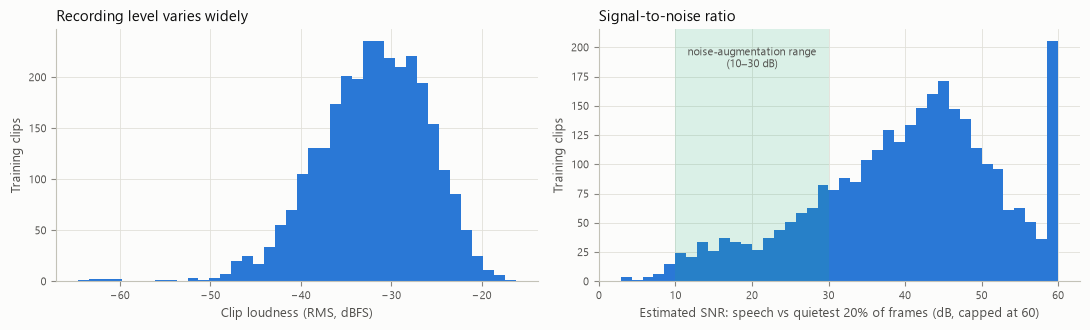

SNR within the 10-30 dB augmentation range: 19% of clips; below 10 dB: 1%; above 30 dB: 80%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(stats.rms_dbfs, bins=40, color=SERIES[0])
axes[0].set(xlabel="Clip loudness (RMS, dBFS)", ylabel="Training clips")
axes[0].set_title("Recording level varies widely", loc="left")
axes[1].hist(stats.snr_db.clip(upper=60), bins=40, color=SERIES[0])
axes[1].axvspan(10, 30, color=SERIES[2], alpha=0.15, lw=0)
axes[1].annotate("noise-augmentation range\n(10–30 dB)", (20, axes[1].get_ylim()[1] * 0.85), ha="center", fontsize=8, color=INK_SECONDARY)
axes[1].set(xlabel="Estimated SNR: speech vs quietest 20% of frames (dB, capped at 60)", ylabel="Training clips")
axes[1].set_title("Signal-to-noise ratio", loc="left")
fig.tight_layout()
save_figure(fig, "eda_loudness_snr")
plt.show()
print(f"SNR within the 10-30 dB augmentation range: {stats.snr_db.between(10, 30).mean():.0%} of clips; "
      f"below 10 dB: {(stats.snr_db < 10).mean():.0%}; above 30 dB: {(stats.snr_db > 30).mean():.0%}")

**→ Decision.**
- **Recording levels vary by about 19 dB** between the 5th and 95th percentiles (−42 to −23 dBFS; median −32 dBFS). 3.8% of clips reach full scale, so may be clipped.
  - So every window is **peak-normalised**, and the HMM also uses per-utterance CMVN.
- **Most recordings are clean.** The median SNR estimate is 42 dB, and 80% of clips exceed 30 dB.
  - So our synthetic noise augmentation (10–30 dB SNR) is *noisier than most real clips*. That is a plausible reason why adding it did not help A3 beyond SpecAugment in R2.
  - A milder range (for example 30–50 dB) would match the data better. We record this as a limitation rather than re-running.

## 5. What the words look like: mean log-mel spectrogram per word (training split, centred 1.5 s window)

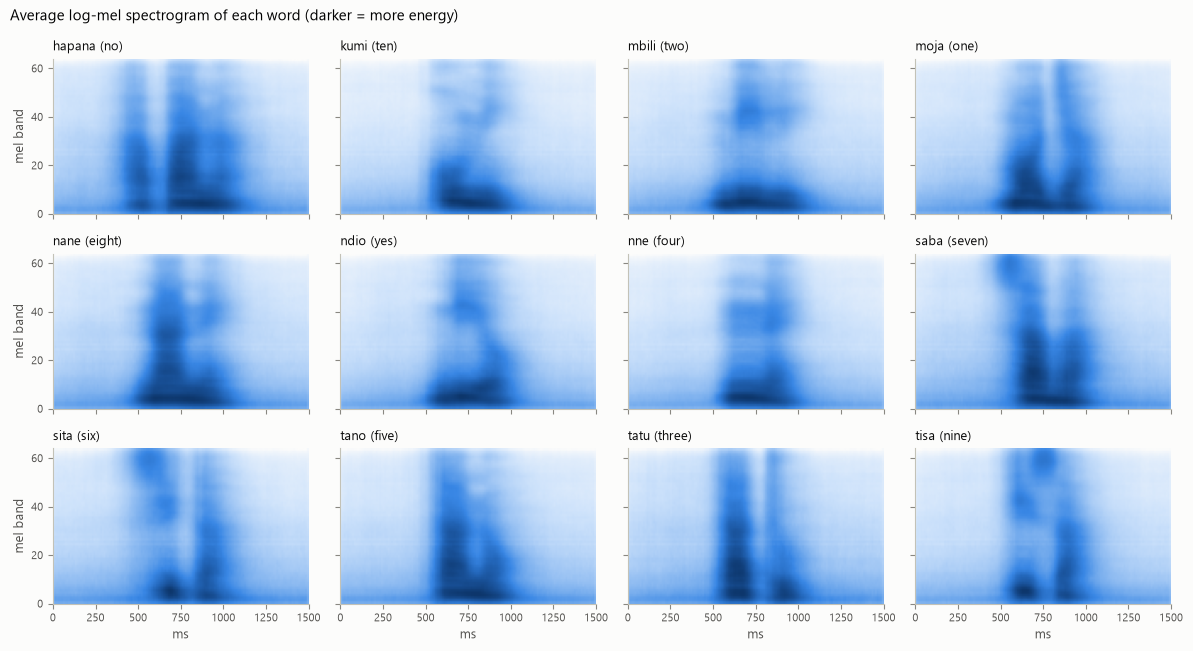

In [8]:
X_tr = cached_features(train, **PRESETS["logmel"])                     # (2940, 151, 64) dB
fig, axes = plt.subplots(3, 4, figsize=(12, 6.6), sharex=True, sharey=True)
for ax, w in zip(axes.flat, NAMES):
    mean_db = X_tr[train.label.to_numpy() == w].mean(0)
    ax.imshow(mean_db.T, origin="lower", aspect="auto", cmap=blue_cmap(), extent=[0, 1500, 0, 64])
    ax.set_title(f"{w} ({GLOSS[w]})", fontsize=9, loc="left")
    ax.grid(False)
for ax in axes[-1]:
    ax.set_xlabel("ms")
for ax in axes[:, 0]:
    ax.set_ylabel("mel band")
fig.suptitle("Average log-mel spectrogram of each word (darker = more energy)", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save_figure(fig, "eda_mean_spectrograms")
plt.show()

**→ Decision.**
- **Each word has a distinct average shape** in time and frequency, centred in the window by the energy crop.
- **The anagram is visible.** The /s/ of *sita* shows as high-frequency energy (the top mel bands) at the **start** of the word. In *tisa* it appears in the **middle**.
  - Same sounds, different order. This is exactly what an order-free summary (A1) averages away, and what the sequence models (A2–A5) can use.
- **64 mel bands at 10 ms resolution** resolve both the vowels' formant structure and the fricatives. So log-mel is the neural models' default input, with MFCC-40 tested as the alternative.

## 6. Phonetic similarity of the vocabulary

anagram pairs (same letters, different order): [('sita', 'tisa')]
Spearman correlation between edit distance and A1's pair confusion over 66 pairs: rho = -0.18 (p = 0.159)


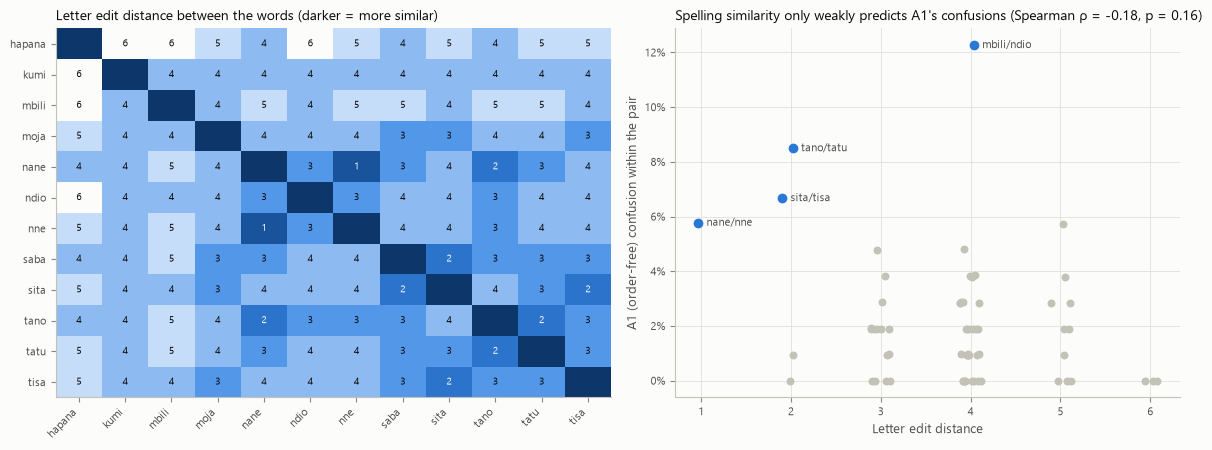

In [9]:
def edit_distance(a, b):
    d = np.arange(len(b) + 1)
    for i, ca in enumerate(a, 1):
        prev, d[0] = d[0], i
        for j, cb in enumerate(b, 1):
            prev, d[j] = d[j], min(d[j] + 1, d[j - 1] + 1, prev + (ca != cb))
    return int(d[-1])


D = np.array([[edit_distance(a, b) for b in NAMES] for a in NAMES])
anagrams = [(a, b) for i, a in enumerate(NAMES) for b in NAMES[i + 1:] if sorted(a) == sorted(b)]
print("anagram pairs (same letters, different order):", anagrams)

# Does spelling similarity predict what the order-free A1 confuses? (A1's logged validation predictions)
a1_file = next(p for p in (RES / "predictions" / "A1-R0-03_seed42_val.csv", REPO_ROOT / "results/predictions/A1-R0-03_seed42_val.csv") if p.exists())
a1, _ = load_predictions(a1_file)
pairs = []
for i, a in enumerate(NAMES):
    for j in range(i + 1, len(NAMES)):
        in_pair = a1.y_true.isin([i, j])
        swapped = ((a1.y_true == i) & (a1.y_pred == j)) | ((a1.y_true == j) & (a1.y_pred == i))
        pairs.append({"pair": f"{a}/{NAMES[j]}", "edit_distance": D[i, j], "a1_confusion": swapped[in_pair].mean()})
pairs = pd.DataFrame(pairs)
from scipy.stats import spearmanr
rho, p = spearmanr(pairs.edit_distance, pairs.a1_confusion)
print(f"Spearman correlation between edit distance and A1's pair confusion over 66 pairs: rho = {rho:.2f} (p = {p:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
ax.imshow(D, cmap=blue_cmap().reversed(), aspect="auto")               # darker = more similar
ax.set_xticks(range(12), NAMES, rotation=45, ha="right")
ax.set_yticks(range(12), NAMES)
ax.grid(False)
for i in range(12):
    for j in range(12):
        if i != j:
            ax.text(j, i, D[i, j], ha="center", va="center", fontsize=7, color="#fcfcfb" if D[i, j] <= 2 else INK)
ax.set_title("Letter edit distance between the words (darker = more similar)", loc="left", fontsize=10)

ax = axes[1]
jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(pairs))
ax.scatter(pairs.edit_distance + jitter, pairs.a1_confusion, s=22, color=DEEMPHASIS, zorder=2)
key = pairs[pairs.pair.isin(["sita/tisa", "nane/nne", "tano/tatu", "mbili/ndio"])]
ax.scatter(key.edit_distance + jitter[key.index], key.a1_confusion, s=36, color=SERIES[0], zorder=3)
for _, r in key.iterrows():
    ax.annotate(r.pair, (r.edit_distance + jitter[r.name], r.a1_confusion), xytext=(6, 0), textcoords="offset points",
                fontsize=8, color=INK_SECONDARY, va="center")
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set(xlabel="Letter edit distance", ylabel="A1 (order-free) confusion within the pair")
ax.set_title(f"Spelling similarity only weakly predicts A1's confusions (Spearman ρ = {rho:.2f}, p = {p:.2f})",
             loc="left", fontsize=10)
fig.tight_layout()
save_figure(fig, "eda_phonetic_similarity")
plt.show()

**→ Decision.**
- ***sita*/*tisa* is the only true anagram in the vocabulary.**
  - The closest spellings are *nne*/*nane* (edit distance 1), then *tano*/*tatu*, *saba*/*sita* and *sita*/*tisa* (distance 2), among others.
  - These define the sound-alike pairs that every model's evaluation tracks (`KEY_PAIRS`).
- **Spelling similarity only weakly predicts what the order-free A1 confuses** (Spearman ρ = −0.18 across all 66 pairs, p = 0.16).
  - A1's most confused pair, *mbili*/*ndio* (12%), is far apart in spelling (distance 4). But both words begin with a prenasalised stop (*mb-*, *nd-*) and contain /i/.
  - So acoustic similarity is not the same as letter similarity, and the error analysis examines confusions directly rather than relying on spelling.

## 7. How separable are the words without temporal order? (t-SNE of MFCC statistics, training split)

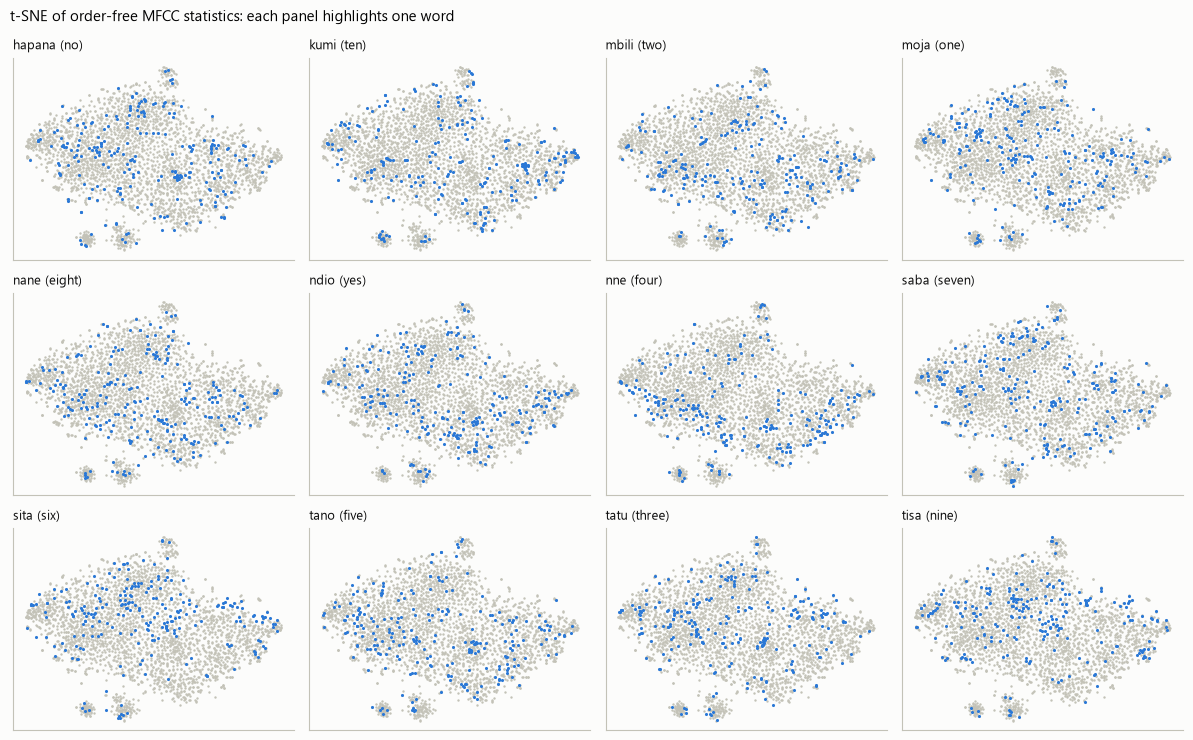

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

tsne_file = RES / "metrics" / "eda_tsne.csv"
if tsne_file.exists() and not RERUN:
    emb = pd.read_csv(tsne_file)
else:
    S = StandardScaler().fit_transform(cached_features(train, **PRESETS["mfcc_stats"]))
    xy = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(S)
    emb = pd.DataFrame({"id": train.id, "x": xy[:, 0], "y": xy[:, 1]})
    emb.to_csv(tsne_file, index=False)
emb = emb.merge(train[["id", "label"]], on="id")

fig, axes = plt.subplots(3, 4, figsize=(12, 7.5), sharex=True, sharey=True)
for ax, w in zip(axes.flat, NAMES):
    other = emb.label != w
    ax.scatter(emb.x[other], emb.y[other], s=3, color=DEEMPHASIS, linewidths=0)
    ax.scatter(emb.x[~other], emb.y[~other], s=5, color=SERIES[0], linewidths=0)
    ax.set_title(f"{w} ({GLOSS[w]})", fontsize=9, loc="left")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("t-SNE of order-free MFCC statistics: each panel highlights one word", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save_figure(fig, "eda_tsne")
plt.show()

**→ Decision.**
- **No word forms its own cluster.** Every word's clips are spread across the whole map. Order-free MFCC statistics do not separate the words well on their own, consistent with A1's ceiling (77.9%).
- **The two small islands at the bottom contain clips of many different words.** So they probably group recordings by speaker or recording condition rather than by word.
- This suggests the order-free statistics carry a lot of channel and speaker information. That supports per-utterance normalisation (CMVN lifted the HMM from 53% to 76%), and models that use temporal structure.

## 8. How early is a word recognisable? (from `02_baselines.ipynb`)
M1 trained the order-free A1 on only the first 25 / 50 / 75 / 100% of each word. The result is repeated here because it shaped the input design.

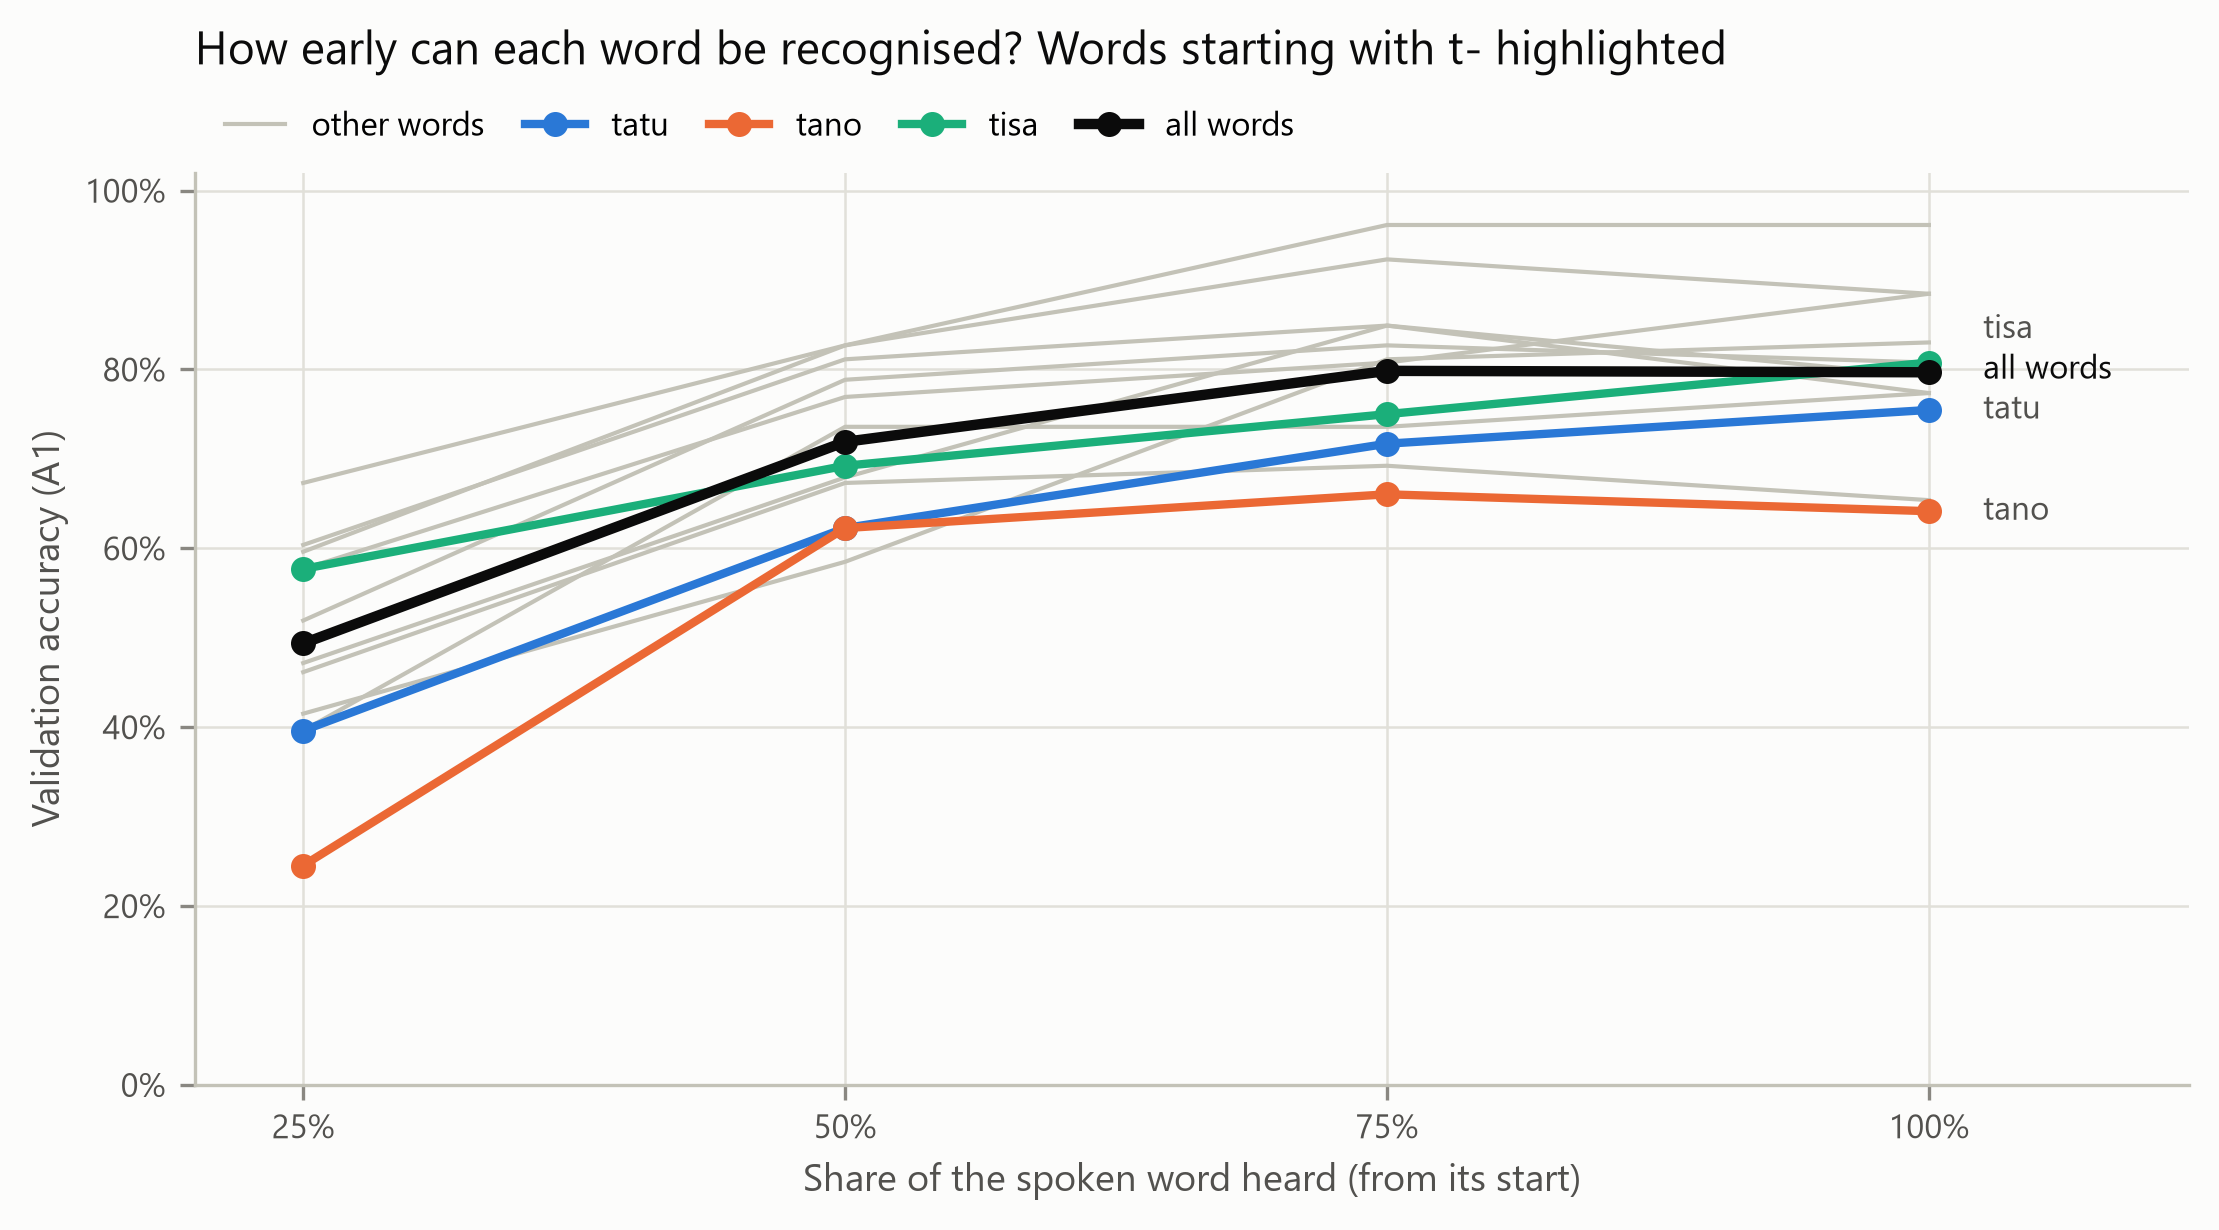

In [11]:
fig_file = next(p for p in (RES / "figures" / "eda8_how_early.png", REPO_ROOT / "results/figures/eda8_how_early.png") if p.exists())
display(Image(filename=str(fig_file), width=720))

**→ Decision.**
- Accuracy rises from 49% (first quarter) to 80% (three quarters), and the last quarter adds nothing.
- Words that share a first syllable (*tano*/*tatu*) are only separated once their second syllable starts.
- So the models must see the **whole word and its order**, not just its onset. The streaming A3 analysis in `03_bilstm.ipynb` confirms this for a learned model.

## 9. Near-duplicates across splits, and speaker variety

In [12]:
from sklearn.preprocessing import normalize

all_clips = pd.concat(splits.values(), keys=splits.keys(), names=["split"]).reset_index(level=0)
V = normalize(StandardScaler().fit_transform(np.vstack([cached_features(splits[s], **PRESETS["mfcc_stats"]) for s in splits])))
sim = V @ V.T
np.fill_diagonal(sim, -1)
i, j = np.where(np.triu(sim > 0.99, 1))
near = pd.DataFrame({"a": all_clips.id.values[i], "b": all_clips.id.values[j], "split_a": all_clips.split.values[i],
                     "split_b": all_clips.split.values[j], "same_label": all_clips.label.values[i] == all_clips.label.values[j]})
print(f"near-duplicate pairs (cosine > 0.99 on standardised MFCC statistics): {len(near)}; "
      f"crossing splits: {(near.split_a != near.split_b).sum()}")
print(f"highest similarity between different clips: {sim.max():.3f}")

near-duplicate pairs (cosine > 0.99 on standardised MFCC statistics): 0; crossing splits: 0
highest similarity between different clips: 0.940


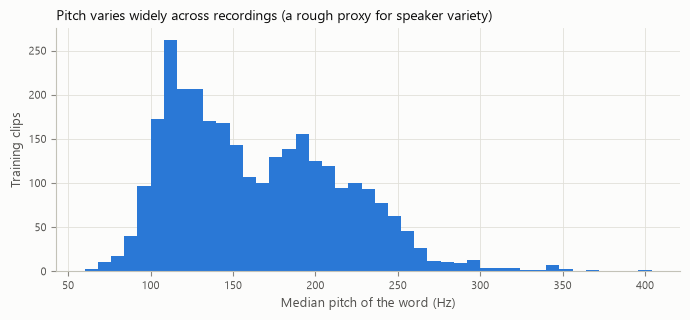

{'count': 2940.0, 'mean': 164.0, 'std': 51.0, 'min': 60.0, '10%': 106.0, '50%': 155.0, '90%': 235.0, 'max': 400.0}


In [13]:
import librosa


def median_f0(path):
    win = energy_crop(load_audio(path), 1.5)
    f0 = librosa.yin(win, fmin=60, fmax=400, sr=TARGET_SR, frame_length=1024, hop_length=160)
    frames = librosa.util.frame(np.pad(win, (512, 512)), frame_length=1024, hop_length=160)[:, : len(f0)]
    energy = 10 * np.log10((frames.astype(np.float64) ** 2).mean(0) + 1e-12)
    voiced = energy >= energy.max() - 20                           # judge pitch only on the loud (vowel) frames
    return float(np.median(f0[voiced])) if voiced.any() else np.nan


f0_file = RES / "metrics" / "eda_pitch.csv"
if f0_file.exists() and not RERUN:
    f0 = pd.read_csv(f0_file)
else:
    f0 = pd.DataFrame({"id": train.id, "f0_hz": Parallel(n_jobs=-1)(delayed(median_f0)(p) for p in train.path)})
    f0.to_csv(f0_file, index=False)

fig, ax = plt.subplots(figsize=(7, 3.3))
ax.hist(f0.f0_hz.dropna(), bins=np.arange(60, 405, 8), color=SERIES[0])
ax.set(xlabel="Median pitch of the word (Hz)", ylabel="Training clips")
ax.set_title("Pitch varies widely across recordings (a rough proxy for speaker variety)", loc="left", fontsize=10)
fig.tight_layout()
save_figure(fig, "eda_pitch")
plt.show()
print(f0.f0_hz.describe(percentiles=[.1, .5, .9]).round(0).to_dict())

**→ Decision.**
- **No near-duplicate recordings.** No pair of clips, across all splits, has a cosine similarity above 0.99 on standardised MFCC statistics; the most similar pair reaches 0.94. So there is no evidence of the same recording appearing in two splits.
- **Pitch varies widely.** The words' median pitch spans 106–235 Hz between the 10th and 90th percentiles (median 155 Hz), consistent with a mix of adult male and female voices among the ~300 speakers.
- **Speaker identities are not provided.** The same speaker may still appear in both train and test, with a different recording, so all scores may be optimistic for unseen speakers. This limitation is carried into the report.

## EDA → design decisions

| # | Finding | Decision |
|---|---|---|
| 1 | 350 clips per word, perfectly balanced | No class weighting. Report accuracy, macro-F1 and the official log loss |
| 2 | All files 16 kHz mono PCM-16; no corrupt files; no duplicates | No resampling; 16 kHz also matches wav2vec2 / XLS-R |
| 3 | Clips 2.5–62 s, but words last a median 0.55 s (≤ 1.0 s for 89.5%); silence trimming leaves long noisy tails | Centred 1.5 s energy window for every model; 1.0 / 2.0 s tested in R2 |
| 4 | Levels spread ~19 dB; 3.8% near clipping; median SNR 42 dB | Peak normalisation; CMVN for the HMM. Our 10–30 dB noise augmentation is harsher than most real clips |
| 5 | Distinct shapes in time and frequency; *sita* and *tisa* differ in *where* the /s/ occurs | 64-band log-mel at 10 ms as the neural input; sequence models needed |
| 6 | One true anagram; spelling similarity only weakly predicts A1's confusions | Track 4 sound-alike pairs; analyse confusions directly |
| 7 | Order-free statistics do not cluster by word; the islands look like recording groups | Per-utterance normalisation; models that use temporal order |
| 8 | Evidence builds up through the word; shared onsets need the second syllable (EDA 8) | Models see the whole word and its order |
| 9 | No near-duplicates across splits; wide pitch range; no speaker IDs | No leakage found; possible speaker overlap noted as a limitation |